In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_excel('Heart Disease.xlsx')
df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [3]:
#pip install --upgrade openpyxl


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  object 
 16  KidneyDisease     31

In [5]:
#pip install openpyxl

In [6]:
df.isnull().sum()

HeartDisease        0
BMI                 0
Smoking             0
AlcoholDrinking     0
Stroke              0
PhysicalHealth      0
MentalHealth        0
DiffWalking         0
Sex                 0
AgeCategory         0
Race                0
Diabetic            0
PhysicalActivity    0
GenHealth           0
SleepTime           0
Asthma              0
KidneyDisease       0
SkinCancer          0
dtype: int64

In [7]:
df.duplicated().sum()

18078

<AxesSubplot:>

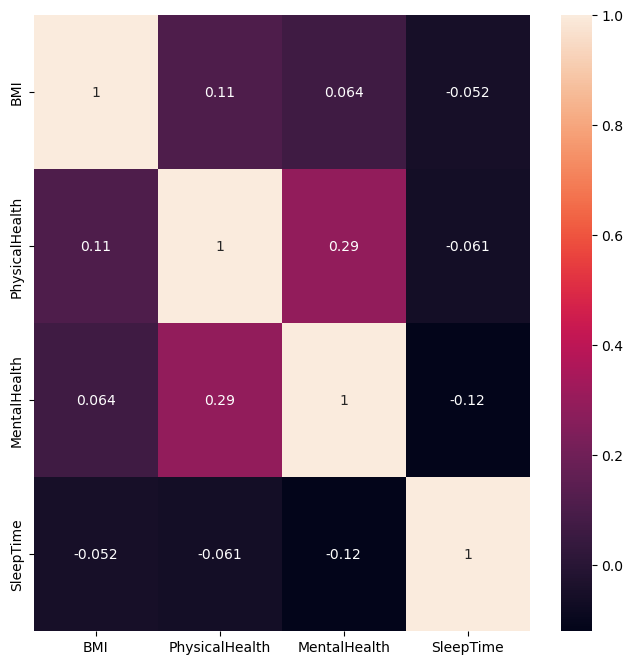

In [8]:
plt.figure(figsize=(8,8))
sns.heatmap(df.corr(),annot=True)

<AxesSubplot:xlabel='Smoking', ylabel='count'>

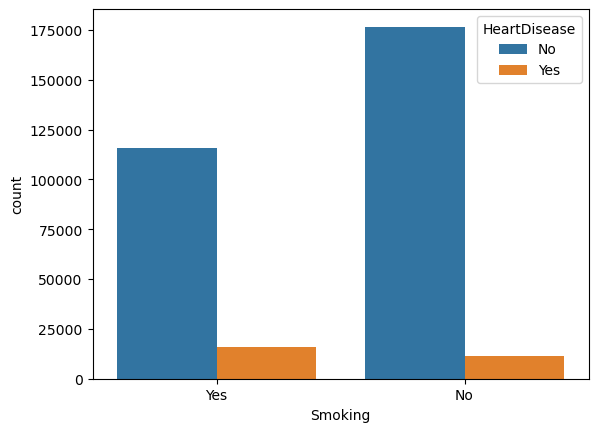

In [9]:
#sns.countplot(df.HeartDisease)
sns.countplot(x='Smoking',hue='HeartDisease',data=df)

# NB: The Dataset is not balanced.

In [10]:
data = df[df['HeartDisease']=='Yes']
data

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
5,Yes,28.87,Yes,No,No,6.0,0.0,Yes,Female,75-79,Black,No,No,Fair,12.0,No,No,No
10,Yes,34.30,Yes,No,No,30.0,0.0,Yes,Male,60-64,White,Yes,No,Poor,15.0,Yes,No,No
35,Yes,32.98,Yes,No,Yes,10.0,0.0,Yes,Male,75-79,White,Yes,Yes,Poor,4.0,No,No,Yes
42,Yes,25.06,No,No,No,0.0,0.0,Yes,Female,80 or older,White,Yes,No,Good,7.0,No,No,Yes
43,Yes,30.23,Yes,No,No,6.0,2.0,Yes,Female,75-79,White,Yes,Yes,Fair,8.0,No,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319765,Yes,38.45,No,No,Yes,30.0,15.0,Yes,Female,55-59,Hispanic,Yes,Yes,Poor,6.0,Yes,No,No
319767,Yes,36.21,Yes,No,No,0.0,0.0,Yes,Female,75-79,Hispanic,Yes,Yes,Good,8.0,No,No,No
319781,Yes,37.12,Yes,No,No,0.0,0.0,No,Male,35-39,Hispanic,No,Yes,Very good,7.0,No,No,No
319786,Yes,33.20,Yes,No,No,0.0,0.0,No,Female,60-64,Hispanic,Yes,Yes,Very good,8.0,Yes,No,No


In [11]:
smoke=data['Smoking'].value_counts()
smoke

Yes    16037
No     11336
Name: Smoking, dtype: int64

In [12]:
labels=["No",'Yes']

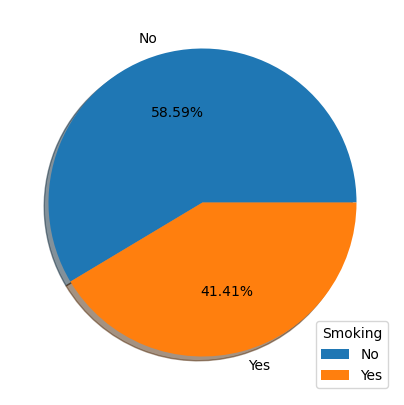

In [13]:
plt.figure(figsize=(5,5))
plt.pie(smoke,labels=labels,autopct='%2.2f%%',shadow=True)#autopct enables you to display the percent value using Python string formatting
plt.legend(title='Smoking',loc='lower right')
plt.show()

In [14]:
def  bar_chart(feature):
    live=df[df['HeartDisease']=='No'][feature].value_counts()
    die=df[df['HeartDisease']=='Yes'][feature].value_counts()
    df1=pd.DataFrame([live,die])
    df1.index=['Live','Die']
    df1.plot(kind='bar',figsize=(10,5))

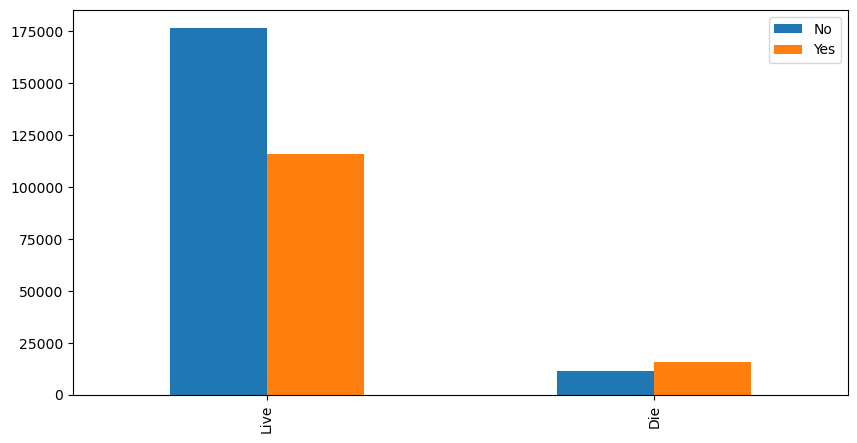

In [15]:
bar_chart('Smoking')

<AxesSubplot:xlabel='BMI', ylabel='Density'>

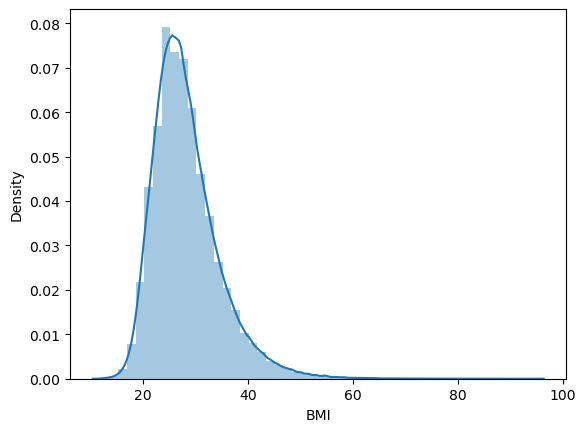

In [16]:
sns.distplot(df['BMI']) #A Distplot or distribution plot, depicts the variation in the data distribution.

In [17]:
def kde(x):
    facet=sns.FacetGrid(df,hue="HeartDisease",aspect=4)
    facet.map(sns.kdeplot,x,shade=True)
    facet.set(xlim=(df[x].min(),df[x].max()))#Limits for each of the axes on each facet (only relevant when share{x, y} is True).
    facet.add_legend()
    plt.show()

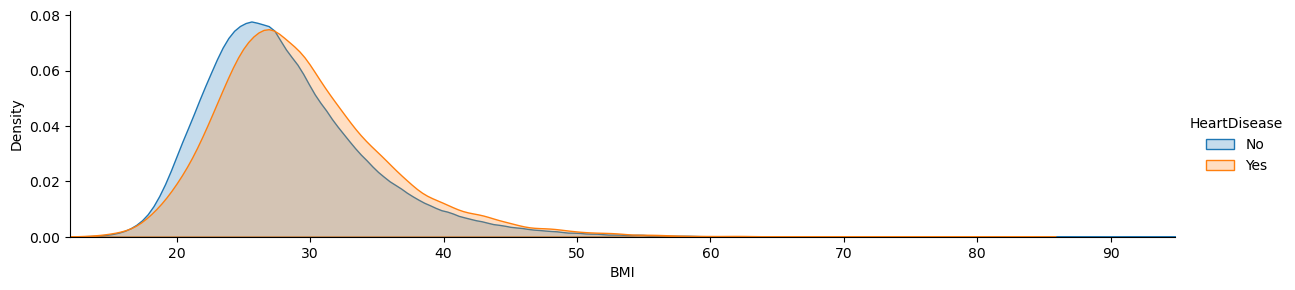

In [18]:
kde('BMI')

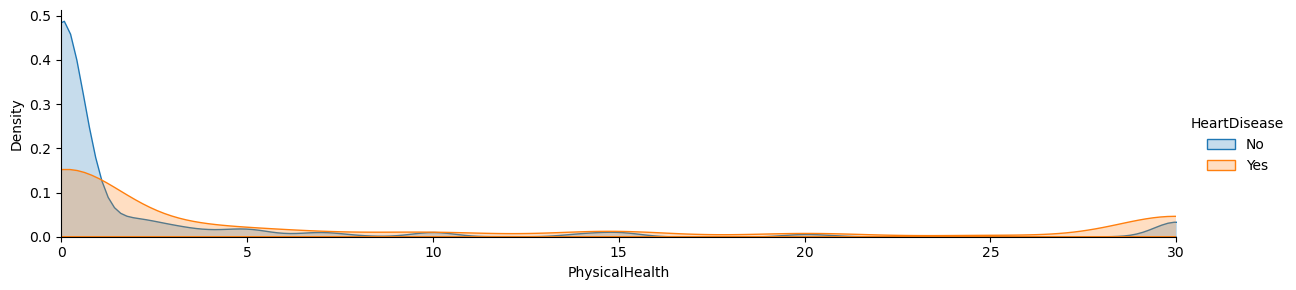

In [19]:
kde('PhysicalHealth')

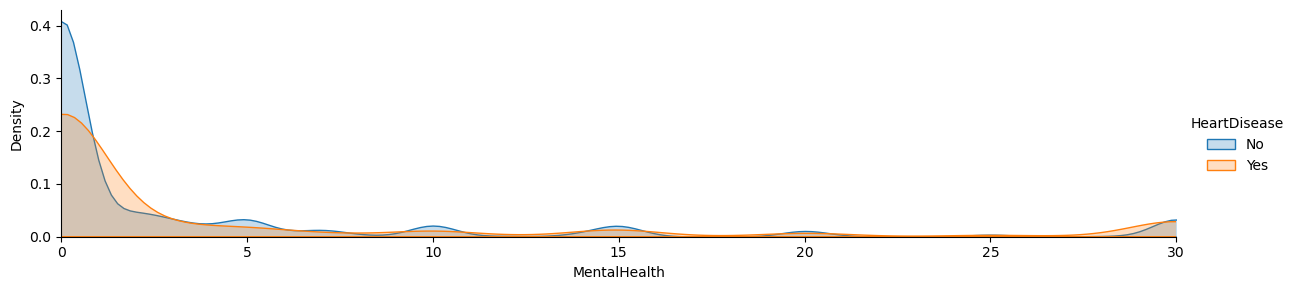

In [20]:
kde('MentalHealth')

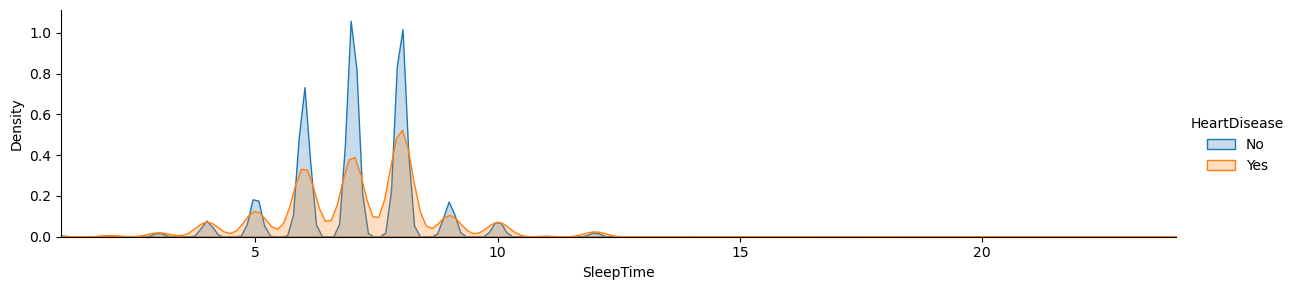

In [21]:
kde('SleepTime')

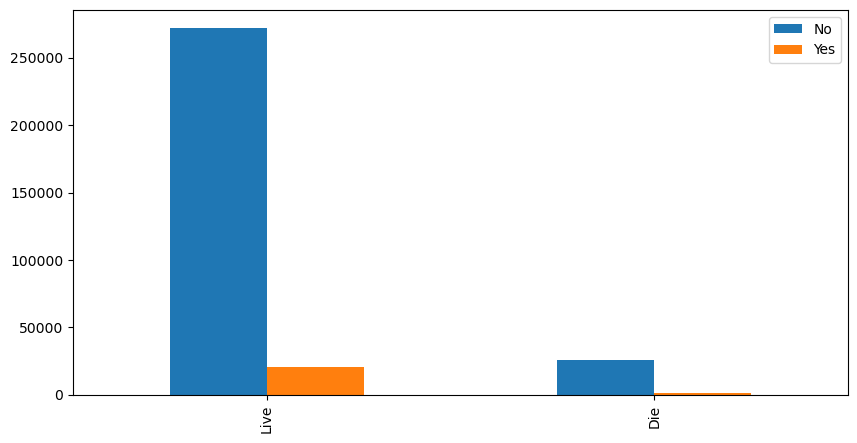

In [22]:
bar_chart('AlcoholDrinking')

In [23]:
AlcoholDrinking=data['AlcoholDrinking'].value_counts()
AlcoholDrinking

No     26232
Yes     1141
Name: AlcoholDrinking, dtype: int64

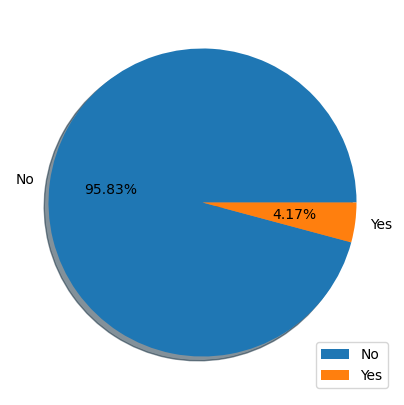

In [24]:
plt.figure(figsize=(5,5))
plt.pie(AlcoholDrinking,labels=labels,autopct='%2.2f%%',shadow=True)#autopct enables you to display the percent value using Python string formatting
plt.legend(title='',loc='lower right')
plt.show()

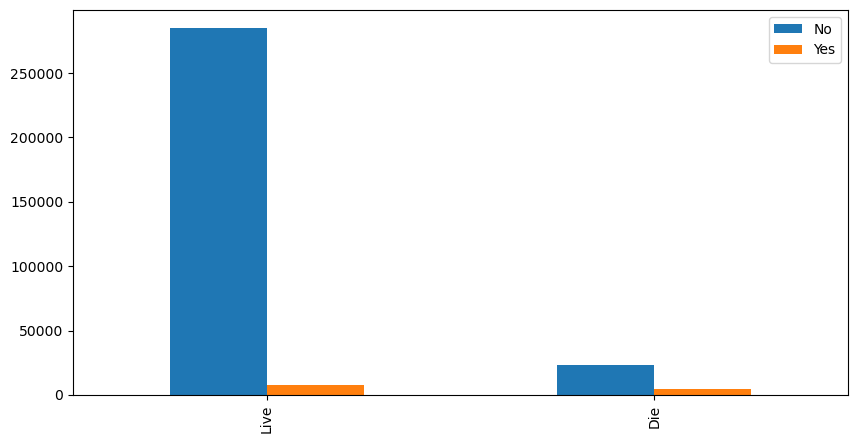

In [25]:
bar_chart('Stroke')

In [26]:
Stroke=data['Stroke'].value_counts()
Stroke

No     22984
Yes     4389
Name: Stroke, dtype: int64

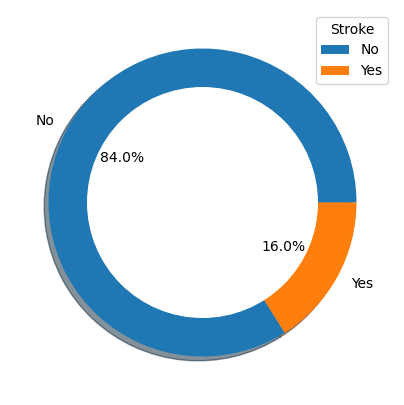

In [27]:
plt.figure(figsize=(5,5))
plt.pie(Stroke,labels=labels,autopct='%2.1f%%',shadow=True)
circle=plt.Circle(xy=(0,0),radius=0.75,facecolor='white')
plt.gca().add_artist(circle)
plt.legend(title='Stroke',loc='upper right')
plt.show()

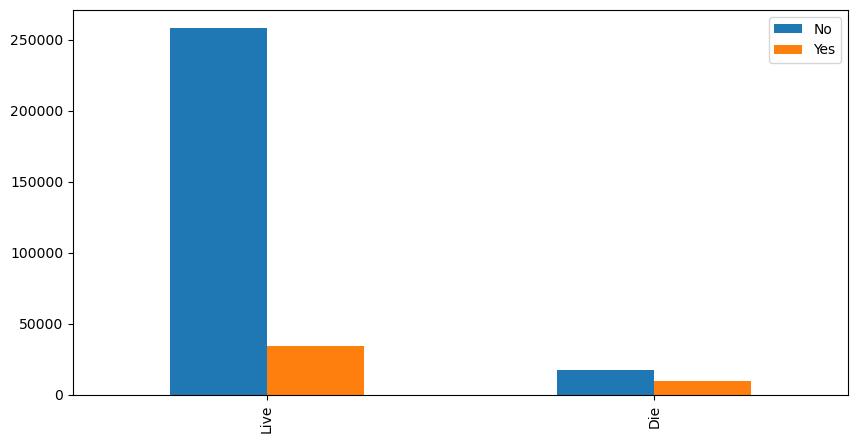

In [28]:
bar_chart('DiffWalking')

In [29]:
DiffWalking=data['DiffWalking'].value_counts()

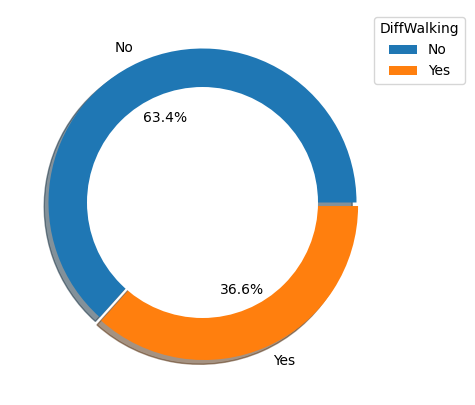

In [30]:
plt.figure(figsize=(5,5))
plt.pie(DiffWalking,labels=labels,explode=[0,0.025] ,autopct='%2.1f%%',shadow=True)
circle=plt.Circle(xy=(0,0),radius=0.75,facecolor='white')
plt.gca().add_artist(circle)
plt.legend(title='DiffWalking',loc='upper right',bbox_to_anchor=(1.2,1))
plt.show()

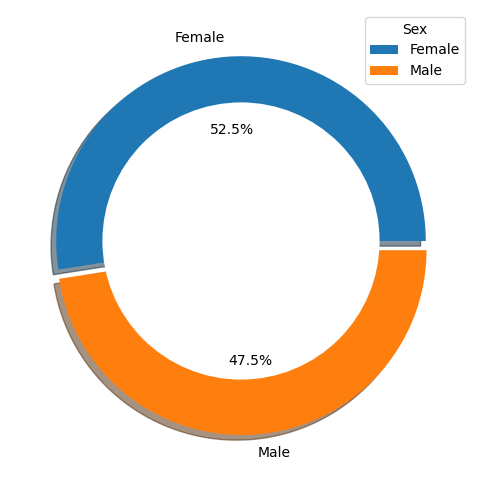

In [31]:
Sex=df['Sex'].value_counts()
Sex
labels=['Female','Male']
plt.figure(figsize=(6,6))
plt.pie(Sex,labels=labels,explode=[0,0.05] ,autopct='%2.1f%%',shadow=True)
circle=plt.Circle(xy=(0,0),radius=0.75,facecolor='white')
plt.gca().add_artist(circle)
plt.legend(title='Sex',loc='upper right')
plt.show()

In [32]:
Race=df['Race'].value_counts()
Race

White                             245212
Hispanic                           27446
Black                              22939
Other                              10928
Asian                               8068
American Indian/Alaskan Native      5202
Name: Race, dtype: int64

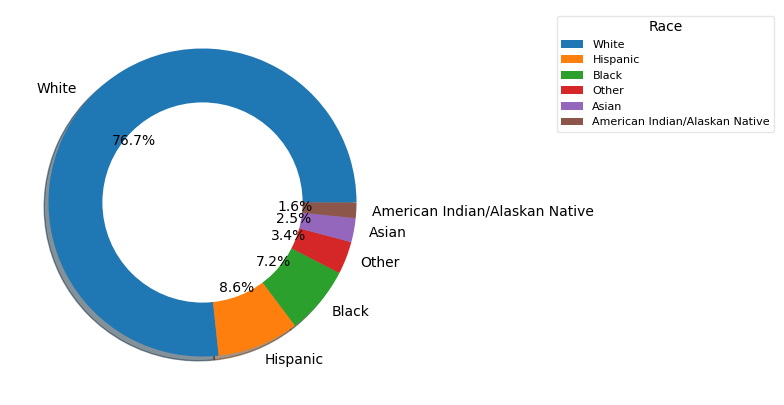

In [33]:
labels=['White','Hispanic','Black','Other','Asian','American Indian/Alaskan Native']
plt.figure(figsize=(5,5))
plt.pie(Race,labels=labels,autopct='%2.1f%%',shadow=True)
circle=plt.Circle(xy=(0,0),radius=0.65,facecolor='white')
plt.gca().add_artist(circle)
plt.legend(title='Race',loc='upper right',framealpha=0.5,fontsize=8,bbox_to_anchor=(2,1))
plt.show()

In [34]:
PhysicalActivity=df['PhysicalActivity'].value_counts()
PhysicalActivity

Yes    247957
No      71838
Name: PhysicalActivity, dtype: int64

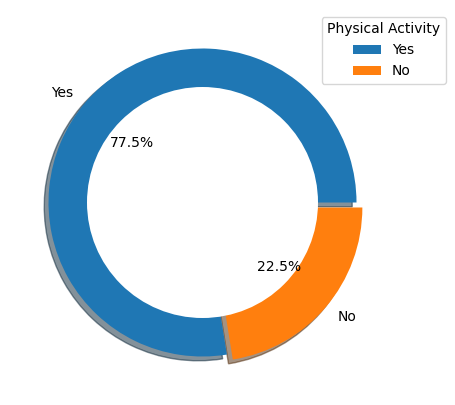

In [35]:
labels=['Yes','No']
plt.figure(figsize=(5,5))
plt.pie(PhysicalActivity,labels=labels,explode=[0,0.05] ,autopct='%2.1f%%',shadow=True)
circle=plt.Circle(xy=(0,0),radius=0.75,facecolor='white')
plt.gca().add_artist(circle)
plt.legend(title='Physical Activity',loc='upper right',bbox_to_anchor=(1.15,1))
plt.show()

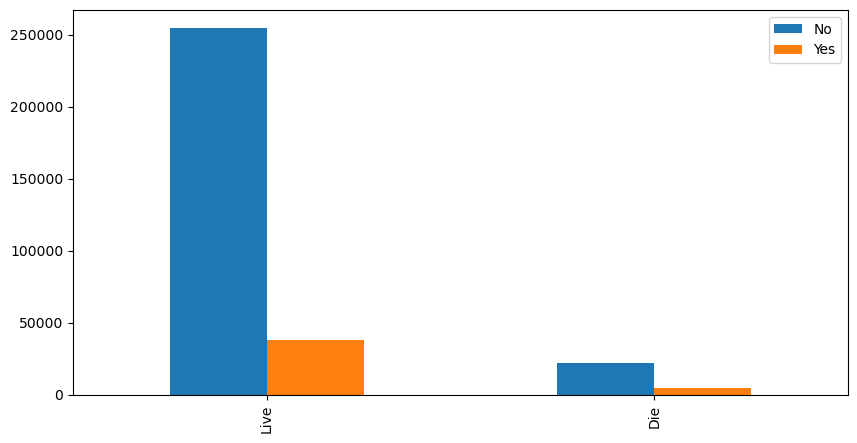

In [36]:
bar_chart('Asthma')


In [37]:
SkinCancer=data['SkinCancer'].value_counts()
SkinCancer

No     22393
Yes     4980
Name: SkinCancer, dtype: int64

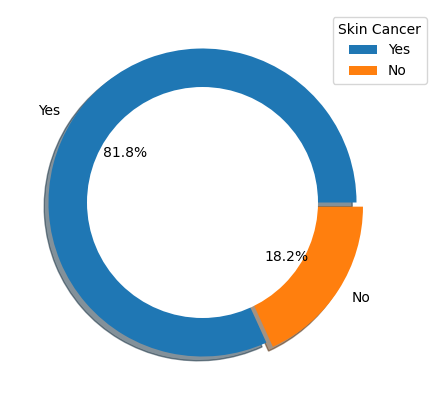

In [38]:
plt.figure(figsize=(5,5))
plt.pie(SkinCancer,labels=labels,explode=[0,0.05] ,autopct='%2.1f%%',shadow=True)
circle=plt.Circle(xy=(0,0),radius=0.75,facecolor='white')
plt.gca().add_artist(circle)
plt.legend(title='Skin Cancer',loc='upper right',bbox_to_anchor=(1.1,1))
plt.show()

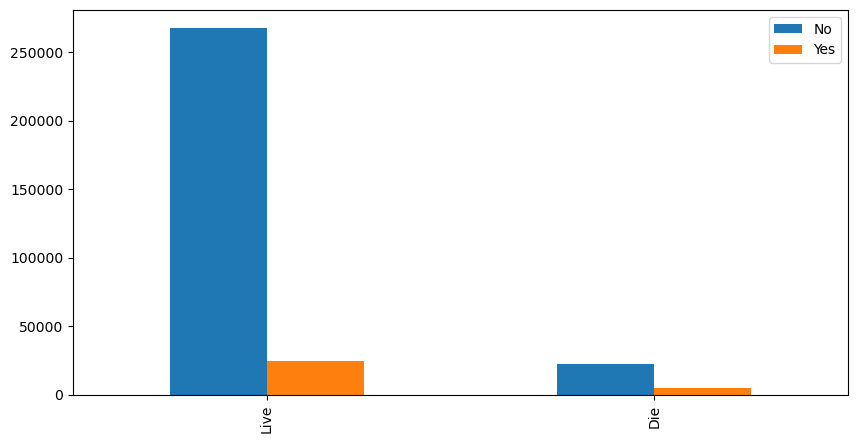

In [39]:
 bar_chart('SkinCancer')

# Data preprocessing for balancing


In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score,mean_absolute_error,accuracy_score

In [41]:
from sklearn.preprocessing import LabelEncoder

In [42]:
le=LabelEncoder()

In [43]:
list=['HeartDisease','Smoking', 'AlcoholDrinking', 'Stroke','DiffWalking', 'Sex', 'AgeCategory',
       'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'Asthma', 'KidneyDisease', 'SkinCancer']
for i in list:
    df[i]=le.fit_transform(df[i])

In [44]:
df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,0,16.60,1,0,0,3.0,30.0,0,0,7,5,2,1,4,5.0,1,0,1
1,0,20.34,0,0,1,0.0,0.0,0,0,12,5,0,1,4,7.0,0,0,0
2,0,26.58,1,0,0,20.0,30.0,0,1,9,5,2,1,1,8.0,1,0,0
3,0,24.21,0,0,0,0.0,0.0,0,0,11,5,0,0,2,6.0,0,0,1
4,0,23.71,0,0,0,28.0,0.0,1,0,4,5,0,1,4,8.0,0,0,0


In [45]:
x=df.drop(columns=['HeartDisease'])
y=df['HeartDisease']

In [46]:
x.sample(10)

,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
66144,28.48,1,0,0,0.0,0.0,0,1,6,5,0,1,0,8.0,0,0,1
304803,28.06,0,0,1,0.0,0.0,0,1,7,5,2,1,2,8.0,0,0,0
204387,29.29,0,0,0,0.0,0.0,1,1,12,5,0,1,2,7.0,0,0,0
115751,29.86,0,1,0,5.0,0.0,0,0,6,5,0,1,4,6.0,0,0,0
94881,27.20,1,0,0,0.0,0.0,0,1,9,5,0,1,2,5.0,0,0,0
313016,46.87,0,0,0,0.0,5.0,0,1,4,5,2,1,4,6.0,0,0,0
248006,20.08,1,0,0,10.0,0.0,0,0,11,5,0,1,1,8.0,1,0,1
149721,29.05,1,0,0,30.0,0.0,1,0,12,5,1,0,1,7.0,0,0,0
214507,22.38,0,0,0,0.0,20.0,0,1,2,5,0,1,0,5.0,1,0,0
45362,25.79,1,0,0,0.0,0.0,0,0,9,5,0,1,4,6.0,0,0,1


# Feature ranking


In [47]:
#df4.nunique()

In [48]:
from sklearn.ensemble import ExtraTreesClassifier # Decison tree

In [49]:
extr = ExtraTreesClassifier()

In [50]:
extr.fit(x,y)

ExtraTreesClassifier()

In [51]:
feature_importance = extr.feature_importances_
feature_importance  

array([0.34213227, 0.01294247, 0.00742663, 0.02991937, 0.0788939 ,
       0.07688465, 0.02617953, 0.01617895, 0.10317763, 0.03809607,
       0.02697313, 0.01770971, 0.05587402, 0.12640559, 0.01501089,
       0.01383019, 0.01236501])

In [52]:
imp = pd.DataFrame(feature_importance, columns=['Gain_Score'])
imp.head(18)

,Gain_Score
0,0.342132
1,0.012942
2,0.007427
3,0.029919
4,0.078894
5,0.076885
6,0.026180
7,0.016179
8,0.103178
9,0.038096


In [53]:
x.columns

Index(['BMI', 'Smoking', 'AlcoholDrinking', 'Stroke', 'PhysicalHealth',
       'MentalHealth', 'DiffWalking', 'Sex', 'AgeCategory', 'Race', 'Diabetic',
       'PhysicalActivity', 'GenHealth', 'SleepTime', 'Asthma', 'KidneyDisease',
       'SkinCancer'],
      dtype='object')

In [54]:
cols = pd.DataFrame(x.columns, columns=['Feature_Names'])
cols.head(18)

,Feature_Names
0,BMI
1,Smoking
2,AlcoholDrinking
3,Stroke
4,PhysicalHealth
5,MentalHealth
6,DiffWalking
7,Sex
8,AgeCategory
9,Race


In [55]:
gains = pd.concat([cols,imp],axis=1)
gains

,Feature_Names,Gain_Score
0,BMI,0.342132
1,Smoking,0.012942
2,AlcoholDrinking,0.007427
3,Stroke,0.029919
4,PhysicalHealth,0.078894
5,MentalHealth,0.076885
6,DiffWalking,0.026180
7,Sex,0.016179
8,AgeCategory,0.103178
9,Race,0.038096


In [56]:
newx = gains.nlargest(18,'Gain_Score')
newx

,Feature_Names,Gain_Score
0,BMI,0.342132
13,SleepTime,0.126406
8,AgeCategory,0.103178
4,PhysicalHealth,0.078894
5,MentalHealth,0.076885
12,GenHealth,0.055874
9,Race,0.038096
3,Stroke,0.029919
10,Diabetic,0.026973
6,DiffWalking,0.026180


<AxesSubplot:xlabel='Gain_Score', ylabel='Feature_Names'>

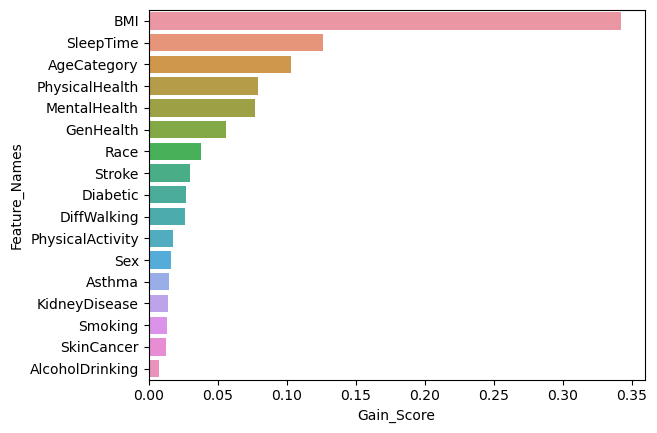

In [57]:
sns.barplot(x='Gain_Score',y='Feature_Names',data=newx)


<AxesSubplot:>

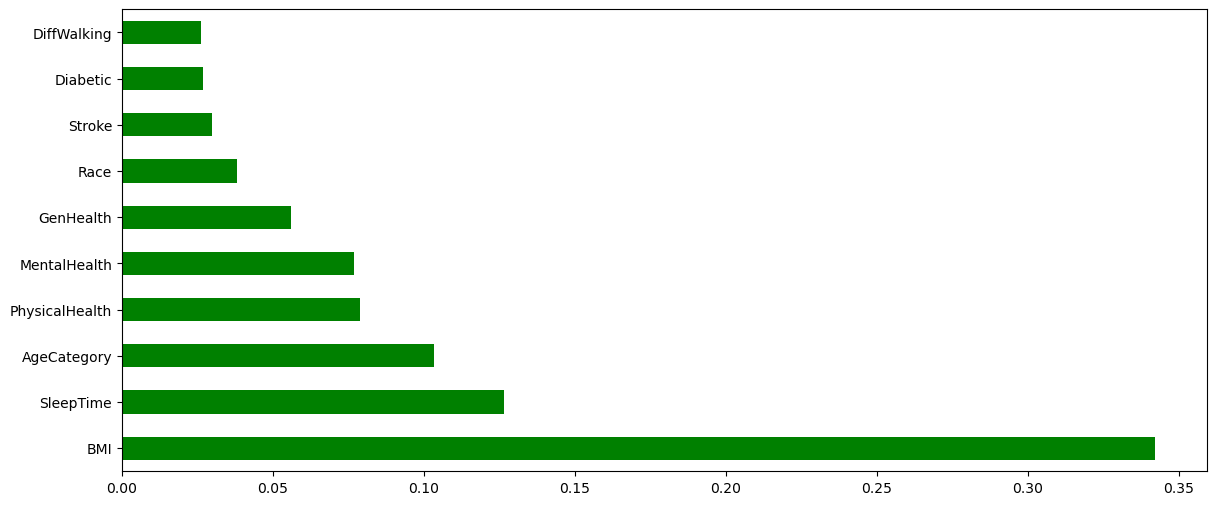

In [58]:
features = pd.Series(extr.feature_importances_, index = x.columns)
plt.figure(figsize=(14,6))
features.nlargest(10).plot(kind='barh', color='g')

# Split Dataset into Train and Test


In [59]:
from sklearn.model_selection import train_test_split

In [37]:
#!pip install imbalanced-learn


In [60]:
import numpy as np

# ---------------- Manual oversampling function ----------------
def oversample(x, y):
    unique, counts = np.unique(y, return_counts=True)
    max_count = max(counts)
    x_res, y_res = [], []

    for cls in unique:
        x_cls = x[y == cls]
        y_cls = y[y == cls]
        reps = max_count // len(x_cls)
        rem = max_count % len(x_cls)
        x_res.append(np.tile(x_cls, (reps, 1)))
        y_res.append(np.tile(y_cls, reps))
        if rem > 0:
            x_res.append(x_cls[:rem])
            y_res.append(y_cls[:rem])

    x_res = np.vstack(x_res)
    y_res = np.hstack(y_res)

    # Shuffle
    idx = np.arange(len(x_res))
    np.random.shuffle(idx)
    return x_res[idx], y_res[idx]

# ---------------- Apply oversampling ----------------
# x and y contain your original dataset
x_bal, y_bal = oversample(x, y)

# ---------------- Separate for model training ----------------
x = x_bal
y = y_bal

# Optional: check new class counts
unique, counts = np.unique(y, return_counts=True)
print("Balanced class counts:", dict(zip(unique, counts)))


Balanced class counts: {0: 292422, 1: 292422}


In [61]:
import pandas as pd

y_series = pd.Series(y)
print(y_series.value_counts())


1    292422
0    292422
dtype: int64


In [62]:
print("x shape after oversampling:", x.shape)


x shape after oversampling: (584844, 17)


In [63]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y_series,train_size=0.8,random_state=42)

In [64]:
#xtest.head(50)

In [65]:
ytest.head(50)

498280    1
103928    0
134719    1
6075      0
547424    1
39474     0
456346    0
52880     1
3721      0
402746    1
388131    0
400936    0
83766     1
383321    0
414893    1
401513    1
482866    1
429567    0
342489    1
196666    1
24877     0
333071    0
433341    0
230030    1
107523    1
51291     1
38939     1
292701    1
34854     1
433641    0
73915     1
490101    1
300898    0
572368    0
103409    0
331273    1
562522    1
171583    1
530105    0
215376    0
408351    0
321981    1
408035    1
512047    0
402668    0
59148     0
95349     1
401540    0
291703    0
91107     0
dtype: int32

Round 1/20 → Loss: 0.5157, Accuracy: 0.7541
Round 2/20 → Loss: 0.5006, Accuracy: 0.7607
Round 3/20 → Loss: 0.4979, Accuracy: 0.7606
Round 4/20 → Loss: 0.4970, Accuracy: 0.7616
Round 5/20 → Loss: 0.4961, Accuracy: 0.7623
Round 6/20 → Loss: 0.4969, Accuracy: 0.7623
Round 7/20 → Loss: 0.4959, Accuracy: 0.7628
Round 8/20 → Loss: 0.4965, Accuracy: 0.7625
Round 9/20 → Loss: 0.4965, Accuracy: 0.7621
Round 10/20 → Loss: 0.4945, Accuracy: 0.7630
Round 11/20 → Loss: 0.4947, Accuracy: 0.7631
Round 12/20 → Loss: 0.4942, Accuracy: 0.7626
Round 13/20 → Loss: 0.4943, Accuracy: 0.7636
Round 14/20 → Loss: 0.4938, Accuracy: 0.7633
Round 15/20 → Loss: 0.4933, Accuracy: 0.7641
Round 16/20 → Loss: 0.4940, Accuracy: 0.7630
Round 17/20 → Loss: 0.4934, Accuracy: 0.7641
Round 18/20 → Loss: 0.4931, Accuracy: 0.7642
Round 19/20 → Loss: 0.4931, Accuracy: 0.7640
Round 20/20 → Loss: 0.4928, Accuracy: 0.7643

Classification Report:
               precision    recall  f1-score   support

           0       0.79      

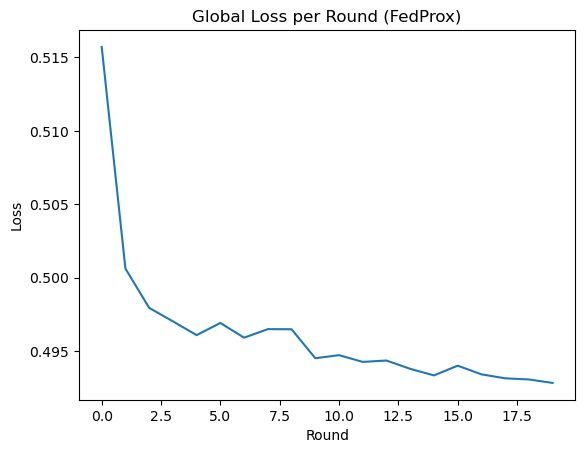

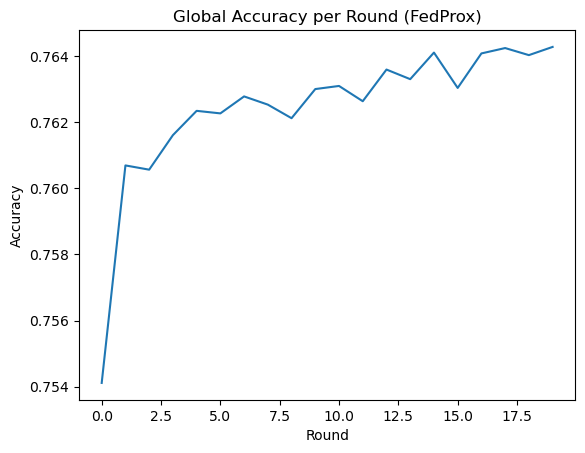

In [67]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, clone_model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

# -------------------------------------------------
# 1. Split dataset into exactly 5 equal clients
# -------------------------------------------------
def split_clients_equal(X, y, n_clients=5):
    n = len(X)
    idx = np.random.permutation(n)
    split_size = n // n_clients

    clients = []
    for i in range(n_clients):
        start = i * split_size
        end = (i + 1) * split_size
        clients.append((X[idx[start:end]], y[idx[start:end]]))

    return clients

# -------------------------------------------------
# 2. Build 1D CNN model
# -------------------------------------------------
def build_1dcnn(input_shape, n_classes):
    model = Sequential([
        Conv1D(32, 3, activation='relu', input_shape=input_shape),
        MaxPooling1D(2),
        Conv1D(64, 3, activation='relu'),
        MaxPooling1D(2),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(n_classes, activation='softmax')
    ])
    return model

# -------------------------------------------------
# 3. Server-side aggregation (FedProx)
# -------------------------------------------------
def server_aggregation(global_model, local_models):
    new_weights = [
        np.mean(w, axis=0)
        for w in zip(*[m.get_weights() for m in local_models])
    ]
    global_model.set_weights(new_weights)
    return global_model

# -------------------------------------------------
# 4. FedProx loss (TensorFlow 2.x safe)
# -------------------------------------------------
def fedprox_loss(mu, global_weights, local_model):
    def loss(y_true, y_pred):
        ce = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        prox = tf.add_n([
            tf.reduce_sum(tf.square(w - gw))
            for w, gw in zip(local_model.trainable_variables, global_weights)
        ])
        return ce + (mu / 2.0) * prox
    return loss

# -------------------------------------------------
# 5. FedProx training procedure
# -------------------------------------------------
def model_fedprox_1dcnn(xtrain, ytrain, xtest, ytest,
                        rounds=20, epochs=2, mu=0.01):

    # Convert to NumPy
    xtrain = np.array(xtrain)
    xtest  = np.array(xtest)
    ytrain = np.array(ytrain)
    ytest  = np.array(ytest)

    # Reshape for Conv1D
    xtrain = xtrain.reshape(xtrain.shape[0], xtrain.shape[1], 1)
    xtest  = xtest.reshape(xtest.shape[0], xtest.shape[1], 1)

    # Create 5 equal clients
    clients = split_clients_equal(xtrain, ytrain, n_clients=5)

    # Initialize global model
    global_model = build_1dcnn(xtrain.shape[1:], len(np.unique(ytrain)))
    global_model.compile(
        optimizer=Adam(0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    global_loss, global_acc = [], []

    # Federated rounds
    for r in range(rounds):
        local_models = []
        global_weights = global_model.get_weights()

        for Xc, yc in clients:
            local_model = clone_model(global_model)
            local_model.set_weights(global_weights)

            local_model.compile(
                optimizer=Adam(0.001),
                loss=fedprox_loss(mu, global_weights, local_model),
                metrics=['accuracy']
            )

            local_model.fit(
                Xc, yc,
                epochs=epochs,
                batch_size=32,
                verbose=0
            )

            local_models.append(local_model)

        # Server aggregation
        global_model = server_aggregation(global_model, local_models)

        loss, acc = global_model.evaluate(xtest, ytest, verbose=0)
        global_loss.append(loss)
        global_acc.append(acc)

        print(f"Round {r+1}/{rounds} → Loss: {loss:.4f}, Accuracy: {acc:.4f}")

    # Final evaluation
    y_pred = np.argmax(global_model.predict(xtest, verbose=0), axis=1)

    print("\nClassification Report:\n",
          classification_report(ytest, y_pred))
    print("Confusion Matrix:\n",
          confusion_matrix(ytest, y_pred))

    # ---- PRINT FULL LISTS ----
    print("\nGlobal Loss per Round:")
    print(global_loss)

    print("\nGlobal Accuracy per Round:")
    print(global_acc)

    # ---- PLOTS ----
    plt.figure()
    plt.plot(global_loss)
    plt.title("Global Loss per Round (FedProx)")
    plt.xlabel("Round")
    plt.ylabel("Loss")
    plt.show()

    plt.figure()
    plt.plot(global_acc)
    plt.title("Global Accuracy per Round (FedProx)")
    plt.xlabel("Round")
    plt.ylabel("Accuracy")
    plt.show()

    return global_model

# -------------------------------------------------
# 6. Run FedProx
# -------------------------------------------------
global_model = model_fedprox_1dcnn(
    xtrain, ytrain, xtest, ytest,
    rounds=20,
    epochs=2,
    mu=0.01
)


In [75]:
global_loss_per_round_CNN = [0.5157158970832825, 0.5006085634231567, 0.49793294072151184, 0.49701276421546936, 0.49607333540916443, 0.49690261483192444, 0.49589842557907104, 0.4964817464351654, 0.4964740574359894, 0.4944998323917389, 0.49470850825309753, 0.4942489564418793, 0.4943426847457886, 0.4937763512134552, 0.4933280348777771, 0.4939919412136078, 0.4934021234512329, 0.4931301474571228, 0.4930514097213745, 0.4928159713745117]


In [76]:
global_accuracy_per_round_CNN = [0.7541143298149109, 0.7606887221336365, 0.7605605125427246, 0.7616034746170044, 0.7623387575149536, 0.7622618079185486, 0.7627747654914856, 0.76252681016922, 0.7621164321899414, 0.762997031211853, 0.7630910873413086, 0.7626293897628784, 0.7635869383811951, 0.7632962465286255, 0.7640998959541321, 0.7630312442779541, 0.7640742659568787, 0.7642366886138916, 0.764022946357727, 0.7642709016799927]

Round 1: Loss=0.5766, Accuracy=0.7221
Round 2: Loss=0.5239, Accuracy=0.7444
Round 3: Loss=0.5193, Accuracy=0.7468
Round 4: Loss=0.5163, Accuracy=0.7500
Round 5: Loss=0.5148, Accuracy=0.7502
Round 6: Loss=0.5170, Accuracy=0.7490
Round 7: Loss=0.5127, Accuracy=0.7529
Round 8: Loss=0.5117, Accuracy=0.7533
Round 9: Loss=0.5102, Accuracy=0.7537
Round 10: Loss=0.5083, Accuracy=0.7560
Round 11: Loss=0.5074, Accuracy=0.7561
Round 12: Loss=0.5081, Accuracy=0.7556
Round 13: Loss=0.5059, Accuracy=0.7566
Round 14: Loss=0.5077, Accuracy=0.7562
Round 15: Loss=0.5069, Accuracy=0.7561
Round 16: Loss=0.5047, Accuracy=0.7589
Round 17: Loss=0.5047, Accuracy=0.7586
Round 18: Loss=0.5035, Accuracy=0.7597
Round 19: Loss=0.5035, Accuracy=0.7599
Round 20: Loss=0.5032, Accuracy=0.7602

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.72      0.75     58331
           1       0.74      0.80      0.77     58638

    accuracy                           0

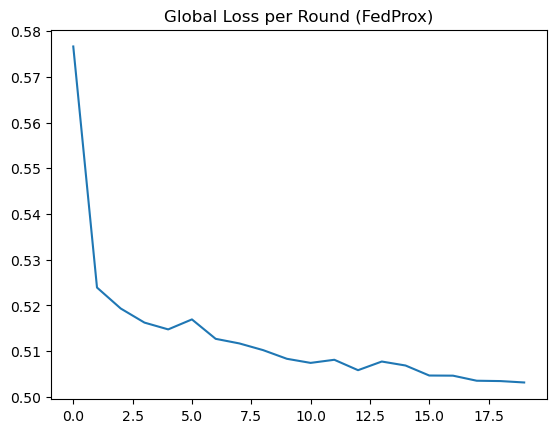

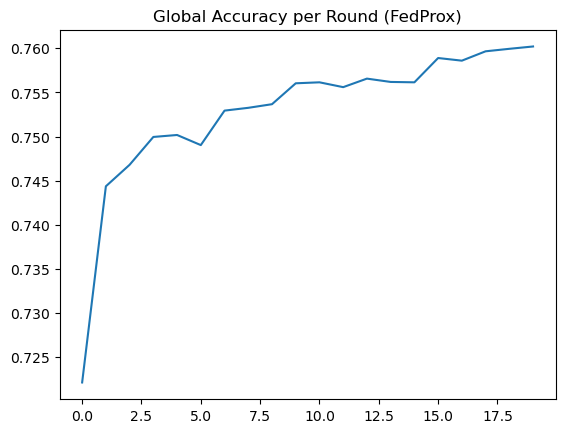

In [68]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, clone_model
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

# -------------------------------------------------
# 1. Split dataset into exactly 5 equal clients
# -------------------------------------------------
def split_clients_equal(X, y, n_clients=5):
    n = len(X)
    idx = np.random.permutation(n)
    split_size = n // n_clients
    clients = [(X[idx[i*split_size:(i+1)*split_size]],
                y[idx[i*split_size:(i+1)*split_size]]) for i in range(n_clients)]
    return clients

# -------------------------------------------------
# 2. Build LSTM model
# -------------------------------------------------
def build_lstm(input_shape, n_classes):
    model = Sequential([
        LSTM(64, input_shape=input_shape, return_sequences=False),
        Dense(64, activation='relu'),
        Dense(n_classes, activation='softmax')
    ])
    return model

# -------------------------------------------------
# 3. Server aggregation
# -------------------------------------------------
def server_aggregation(global_model, local_models):
    new_weights = [np.mean(w, axis=0) for w in zip(*[m.get_weights() for m in local_models])]
    global_model.set_weights(new_weights)
    return global_model

# -------------------------------------------------
# 4. FedProx loss
# -------------------------------------------------
def fedprox_loss(mu, global_weights, local_model):
    def loss(y_true, y_pred):
        ce = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        prox = tf.add_n([tf.reduce_sum(tf.square(w - gw)) 
                         for w, gw in zip(local_model.trainable_variables, global_weights)])
        return ce + (mu / 2.0) * prox
    return loss

# -------------------------------------------------
# 5. FedProx training
# -------------------------------------------------
def model_fedprox_lstm(xtrain, ytrain, xtest, ytest,
                        n_clients=5, rounds=20, epochs=2, mu=0.01):

    # Convert to NumPy arrays
    xtrain = np.array(xtrain)
    xtest  = np.array(xtest)
    ytrain = np.array(ytrain)
    ytest  = np.array(ytest)

    # Reshape for LSTM: (samples, timesteps, features)
    xtrain = xtrain.reshape(xtrain.shape[0], xtrain.shape[1], 1)
    xtest  = xtest.reshape(xtest.shape[0], xtest.shape[1], 1)

    # Split clients
    clients = split_clients_equal(xtrain, ytrain, n_clients)

    # Initialize global model
    global_model = build_lstm(xtrain.shape[1:], len(np.unique(ytrain)))
    global_model.compile(optimizer=Adam(0.001), 
                         loss='sparse_categorical_crossentropy',
                         metrics=['accuracy'])

    global_loss, global_acc = [], []

    # Federated rounds
    for r in range(rounds):
        local_models = []
        global_weights = global_model.get_weights()

        for Xc, yc in clients:
            local_model = clone_model(global_model)
            local_model.set_weights(global_weights)
            local_model.compile(
                optimizer=Adam(0.001),
                loss=fedprox_loss(mu, global_weights, local_model),
                metrics=['accuracy']
            )
            local_model.fit(Xc, yc, epochs=epochs, batch_size=32, verbose=0)
            local_models.append(local_model)

        # Server aggregation
        global_model = server_aggregation(global_model, local_models)

        # Evaluate
        loss, acc = global_model.evaluate(xtest, ytest, verbose=0)
        global_loss.append(loss)
        global_acc.append(acc)
        print(f"Round {r+1}: Loss={loss:.4f}, Accuracy={acc:.4f}")

    # Final evaluation
    y_pred = np.argmax(global_model.predict(xtest, verbose=0), axis=1)
    print("\nClassification Report:\n", classification_report(ytest, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(ytest, y_pred))

    # Print full lists
    print("\nGlobal Loss per Round:")
    print(global_loss)
    print("\nGlobal Accuracy per Round:")
    print(global_acc)

    # Plot
    plt.figure(); plt.plot(global_loss); plt.title("Global Loss per Round (FedProx)"); plt.show()
    plt.figure(); plt.plot(global_acc); plt.title("Global Accuracy per Round (FedProx)"); plt.show()

    return global_model

# ------------------ CALL FUNCTION ------------------
global_model = model_fedprox_lstm(xtrain, ytrain, xtest, ytest,
                                  n_clients=5, rounds=20, epochs=2, mu=0.01)


In [74]:
Global_Loss_per_Round_LSTM = [0.576623260974884, 0.5239213109016418, 0.5193377733230591, 0.5162579417228699, 0.5147719383239746, 0.5169551372528076, 0.5127105712890625, 0.511703610420227, 0.5102400779724121, 0.5083479285240173, 0.5074485540390015, 0.5081314444541931, 0.5058555006980896, 0.5077469348907471, 0.5068789124488831, 0.504688560962677, 0.5046589970588684, 0.5035494565963745, 0.5034746527671814, 0.5031680464744568]


Global_Accuracy_per_Round_LSTM = [0.7221314907073975, 0.7443596124649048, 0.7467961311340332, 0.7499508261680603, 0.7501731514930725, 0.7490274906158447, 0.7529345154762268, 0.7532508373260498, 0.7536612153053284, 0.7560293674468994, 0.7561405301094055, 0.7555933594703674, 0.756559431552887, 0.7561832666397095, 0.7561405301094055, 0.7588933706283569, 0.7585941553115845, 0.7596542835235596, 0.7599363923072815, 0.7602013945579529]

Round 1: Loss=0.5644, Accuracy=0.7114
Round 2: Loss=0.5246, Accuracy=0.7433
Round 3: Loss=0.5227, Accuracy=0.7448
Round 4: Loss=0.5179, Accuracy=0.7481
Round 5: Loss=0.5161, Accuracy=0.7491
Round 6: Loss=0.5178, Accuracy=0.7477
Round 7: Loss=0.5132, Accuracy=0.7513
Round 8: Loss=0.5124, Accuracy=0.7524
Round 9: Loss=0.5113, Accuracy=0.7531
Round 10: Loss=0.5118, Accuracy=0.7520
Round 11: Loss=0.5098, Accuracy=0.7546
Round 12: Loss=0.5089, Accuracy=0.7550
Round 13: Loss=0.5082, Accuracy=0.7549
Round 14: Loss=0.5076, Accuracy=0.7550
Round 15: Loss=0.5067, Accuracy=0.7558
Round 16: Loss=0.5069, Accuracy=0.7564
Round 17: Loss=0.5089, Accuracy=0.7544
Round 18: Loss=0.5055, Accuracy=0.7573
Round 19: Loss=0.5050, Accuracy=0.7574
Round 20: Loss=0.5078, Accuracy=0.7548

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.75      0.75     58331
           1       0.75      0.76      0.76     58638

    accuracy                           0

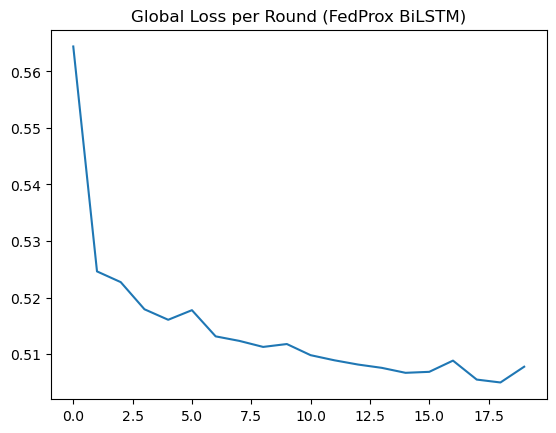

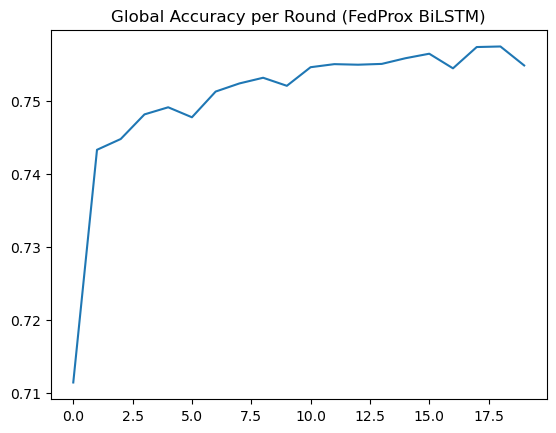

In [69]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, clone_model
from tensorflow.keras.layers import Bidirectional, LSTM, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

# -------------------------------------------------
# 1. Split dataset into exactly 5 equal clients
# -------------------------------------------------
def split_clients_equal(X, y, n_clients=5):
    n = len(X)
    idx = np.random.permutation(n)
    split_size = n // n_clients
    clients = [(X[idx[i*split_size:(i+1)*split_size]],
                y[idx[i*split_size:(i+1)*split_size]]) for i in range(n_clients)]
    return clients

# -------------------------------------------------
# 2. Build BiLSTM model
# -------------------------------------------------
def build_bilstm(input_shape, n_classes):
    model = Sequential([
        Bidirectional(LSTM(64, return_sequences=False), input_shape=input_shape),
        Dense(64, activation='relu'),
        Dense(n_classes, activation='softmax')
    ])
    return model

# -------------------------------------------------
# 3. Server aggregation
# -------------------------------------------------
def server_aggregation(global_model, local_models):
    new_weights = [np.mean(w, axis=0) for w in zip(*[m.get_weights() for m in local_models])]
    global_model.set_weights(new_weights)
    return global_model

# -------------------------------------------------
# 4. FedProx loss
# -------------------------------------------------
def fedprox_loss(mu, global_weights, local_model):
    def loss(y_true, y_pred):
        ce = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        prox = tf.add_n([tf.reduce_sum(tf.square(w - gw)) 
                         for w, gw in zip(local_model.trainable_variables, global_weights)])
        return ce + (mu / 2.0) * prox
    return loss

# -------------------------------------------------
# 5. FedProx training
# -------------------------------------------------
def model_fedprox_bilstm(xtrain, ytrain, xtest, ytest,
                         n_clients=5, rounds=20, epochs=2, mu=0.01):

    # Convert to NumPy arrays
    xtrain = np.array(xtrain)
    xtest  = np.array(xtest)
    ytrain = np.array(ytrain)
    ytest  = np.array(ytest)

    # Reshape for BiLSTM: (samples, timesteps, features)
    xtrain = xtrain.reshape(xtrain.shape[0], xtrain.shape[1], 1)
    xtest  = xtest.reshape(xtest.shape[0], xtest.shape[1], 1)

    # Split clients
    clients = split_clients_equal(xtrain, ytrain, n_clients)

    # Initialize global model
    global_model = build_bilstm(xtrain.shape[1:], len(np.unique(ytrain)))
    global_model.compile(optimizer=Adam(0.001),
                         loss='sparse_categorical_crossentropy',
                         metrics=['accuracy'])

    global_loss, global_acc = [], []

    # Federated rounds
    for r in range(rounds):
        local_models = []
        global_weights = global_model.get_weights()

        for Xc, yc in clients:
            local_model = clone_model(global_model)
            local_model.set_weights(global_weights)
            local_model.compile(
                optimizer=Adam(0.001),
                loss=fedprox_loss(mu, global_weights, local_model),
                metrics=['accuracy']
            )
            local_model.fit(Xc, yc, epochs=epochs, batch_size=32, verbose=0)
            local_models.append(local_model)

        # Server aggregation
        global_model = server_aggregation(global_model, local_models)

        # Evaluate
        loss, acc = global_model.evaluate(xtest, ytest, verbose=0)
        global_loss.append(loss)
        global_acc.append(acc)
        print(f"Round {r+1}: Loss={loss:.4f}, Accuracy={acc:.4f}")

    # Final evaluation
    y_pred = np.argmax(global_model.predict(xtest, verbose=0), axis=1)
    print("\nClassification Report:\n", classification_report(ytest, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(ytest, y_pred))

    # Print full lists
    print("\nGlobal Loss per Round:")
    print(global_loss)
    print("\nGlobal Accuracy per Round:")
    print(global_acc)

    # Plot
    plt.figure(); plt.plot(global_loss); plt.title("Global Loss per Round (FedProx BiLSTM)"); plt.show()
    plt.figure(); plt.plot(global_acc); plt.title("Global Accuracy per Round (FedProx BiLSTM)"); plt.show()

    return global_model

# ------------------ CALL FUNCTION ------------------
global_model = model_fedprox_bilstm(xtrain, ytrain, xtest, ytest,
                                    n_clients=5, rounds=20, epochs=2, mu=0.01)


In [72]:
Global_Loss_per_Round_BiLSTM = [0.5643986463546753, 0.524636447429657, 0.5227400660514832, 0.5179420113563538, 0.5160844326019287, 0.5177822709083557, 0.5131521224975586, 0.5123515129089355, 0.5112869739532471, 0.5117958784103394, 0.509828507900238, 0.5089254975318909, 0.5081700086593628, 0.5075872540473938, 0.5067079663276672, 0.5068824291229248, 0.5088664889335632, 0.5055142045021057, 0.5050008296966553, 0.5077886581420898]


Global_Accuracy_per_Round_BiLSTM = [0.7114107012748718, 0.7432738542556763, 0.7447528839111328, 0.7481213212013245, 0.7490959167480469, 0.7477280497550964, 0.7512503266334534, 0.7523617148399353, 0.7531397342681885, 0.7520368695259094, 0.754584550857544, 0.7550034523010254, 0.7549265027046204, 0.7550376653671265, 0.7558156251907349, 0.7564311623573303, 0.7544306516647339, 0.757345974445343, 0.757422924041748, 0.7548239231109619]

Round 1: Loss=0.5374, Accuracy=0.7399
Round 2: Loss=0.5145, Accuracy=0.7517
Round 3: Loss=0.5158, Accuracy=0.7509
Round 4: Loss=0.5110, Accuracy=0.7536
Round 5: Loss=0.5085, Accuracy=0.7560
Round 6: Loss=0.5082, Accuracy=0.7564
Round 7: Loss=0.5087, Accuracy=0.7548
Round 8: Loss=0.5054, Accuracy=0.7577
Round 9: Loss=0.5048, Accuracy=0.7577
Round 10: Loss=0.5057, Accuracy=0.7566
Round 11: Loss=0.5043, Accuracy=0.7579
Round 12: Loss=0.5026, Accuracy=0.7583
Round 13: Loss=0.5011, Accuracy=0.7595
Round 14: Loss=0.5003, Accuracy=0.7595
Round 15: Loss=0.4986, Accuracy=0.7610
Round 16: Loss=0.4985, Accuracy=0.7606
Round 17: Loss=0.4974, Accuracy=0.7622
Round 18: Loss=0.4967, Accuracy=0.7616
Round 19: Loss=0.4957, Accuracy=0.7629
Round 20: Loss=0.4950, Accuracy=0.7635

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.70      0.75     58331
           1       0.73      0.83      0.78     58638

    accuracy                           0

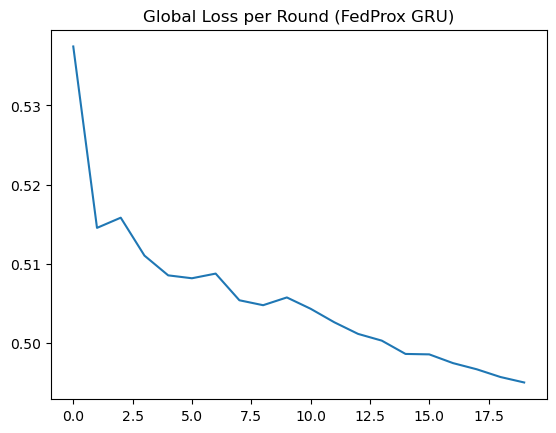

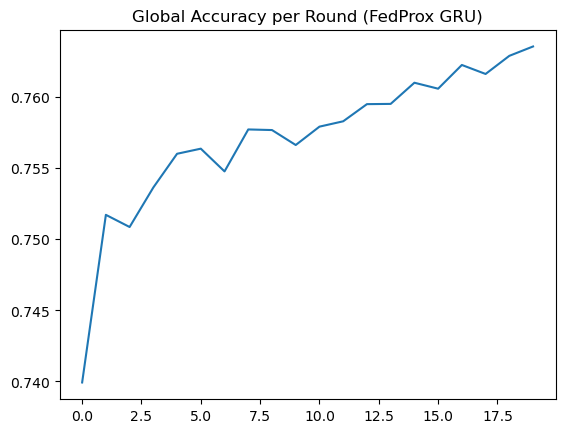

In [71]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, clone_model
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

# -------------------------------------------------
# 1. Split dataset into exactly 5 equal clients
# -------------------------------------------------
def split_clients_equal(X, y, n_clients=5):
    n = len(X)
    idx = np.random.permutation(n)
    split_size = n // n_clients
    clients = [(X[idx[i*split_size:(i+1)*split_size]],
                y[idx[i*split_size:(i+1)*split_size]]) for i in range(n_clients)]
    return clients

# -------------------------------------------------
# 2. Build GRU model
# -------------------------------------------------
def build_gru(input_shape, n_classes):
    model = Sequential([
        GRU(64, return_sequences=False, input_shape=input_shape),
        Dense(64, activation='relu'),
        Dense(n_classes, activation='softmax')
    ])
    return model

# -------------------------------------------------
# 3. Server aggregation
# -------------------------------------------------
def server_aggregation(global_model, local_models):
    new_weights = [np.mean(w, axis=0) for w in zip(*[m.get_weights() for m in local_models])]
    global_model.set_weights(new_weights)
    return global_model

# -------------------------------------------------
# 4. FedProx loss
# -------------------------------------------------
def fedprox_loss(mu, global_weights, local_model):
    def loss(y_true, y_pred):
        ce = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        prox = tf.add_n([tf.reduce_sum(tf.square(w - gw)) 
                         for w, gw in zip(local_model.trainable_variables, global_weights)])
        return ce + (mu / 2.0) * prox
    return loss

# -------------------------------------------------
# 5. FedProx training
# -------------------------------------------------
def model_fedprox_gru(xtrain, ytrain, xtest, ytest,
                       n_clients=5, rounds=20, epochs=2, mu=0.01):

    # Convert to NumPy arrays
    xtrain = np.array(xtrain)
    xtest  = np.array(xtest)
    ytrain = np.array(ytrain)
    ytest  = np.array(ytest)

    # Reshape for GRU: (samples, timesteps, features)
    xtrain = xtrain.reshape(xtrain.shape[0], xtrain.shape[1], 1)
    xtest  = xtest.reshape(xtest.shape[0], xtest.shape[1], 1)

    # Split clients
    clients = split_clients_equal(xtrain, ytrain, n_clients)

    # Initialize global model
    global_model = build_gru(xtrain.shape[1:], len(np.unique(ytrain)))
    global_model.compile(optimizer=Adam(0.001),
                         loss='sparse_categorical_crossentropy',
                         metrics=['accuracy'])

    # Initialize lists to store global metrics
    global_loss = []
    global_acc = []

    # Federated rounds
    for r in range(rounds):
        local_models = []
        global_weights = global_model.get_weights()

        for Xc, yc in clients:
            local_model = clone_model(global_model)
            local_model.set_weights(global_weights)
            local_model.compile(
                optimizer=Adam(0.001),
                loss=fedprox_loss(mu, global_weights, local_model),
                metrics=['accuracy']
            )
            local_model.fit(Xc, yc, epochs=epochs, batch_size=32, verbose=0)
            local_models.append(local_model)

        # Server aggregation
        global_model = server_aggregation(global_model, local_models)

        # Evaluate
        loss, acc = global_model.evaluate(xtest, ytest, verbose=0)
        global_loss.append(loss)
        global_acc.append(acc)
        print(f"Round {r+1}: Loss={loss:.4f}, Accuracy={acc:.4f}")

    # Final evaluation
    y_pred = np.argmax(global_model.predict(xtest, verbose=0), axis=1)
    print("\nClassification Report:\n", classification_report(ytest, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(ytest, y_pred))

    # Print full lists
    print("\nGlobal Loss per Round:")
    print(global_loss)
    print("\nGlobal Accuracy per Round:")
    print(global_acc)

    # Plot
    plt.figure(); plt.plot(global_loss); plt.title("Global Loss per Round (FedProx GRU)"); plt.show()
    plt.figure(); plt.plot(global_acc); plt.title("Global Accuracy per Round (FedProx GRU)"); plt.show()

    return global_model

# ------------------ CALL FUNCTION ------------------
global_model = model_fedprox_gru(xtrain, ytrain, xtest, ytest,
                                 n_clients=5, rounds=20, epochs=2, mu=0.01)


In [77]:
Global_Loss_per_Round_GRU = [0.537438690662384, 0.5145218968391418, 0.5158096551895142, 0.5110183358192444, 0.5085241198539734, 0.5081574320793152, 0.5087469220161438, 0.5053775310516357, 0.5047539472579956, 0.5057341456413269, 0.5043057203292847, 0.5025964975357056, 0.5011298060417175, 0.5002785921096802, 0.49859777092933655, 0.49854233860969543, 0.4974396228790283, 0.4966595768928528, 0.4956825077533722, 0.4949921667575836]

Global_Accuracy_per_Round_GRU = [0.7399311065673828, 0.7517119646072388, 0.7508570551872253, 0.753635585308075, 0.756003737449646, 0.756362795829773, 0.7547640800476074, 0.7577135562896729, 0.7576708197593689, 0.7566192746162415, 0.7579101920127869, 0.7582863569259644, 0.7594918608665466, 0.7595089077949524, 0.7609965205192566, 0.7605775594711304, 0.762244701385498, 0.761612057685852, 0.7628858685493469, 0.7635442018508911]

Round 1: Loss=0.5455, Accuracy=0.7268
Round 2: Loss=0.5235, Accuracy=0.7441
Round 3: Loss=0.5183, Accuracy=0.7474
Round 4: Loss=0.5156, Accuracy=0.7510
Round 5: Loss=0.5106, Accuracy=0.7546
Round 6: Loss=0.5080, Accuracy=0.7555
Round 7: Loss=0.5058, Accuracy=0.7580
Round 8: Loss=0.5055, Accuracy=0.7587
Round 9: Loss=0.5036, Accuracy=0.7594
Round 10: Loss=0.5030, Accuracy=0.7594
Round 11: Loss=0.5037, Accuracy=0.7589
Round 12: Loss=0.5027, Accuracy=0.7606
Round 13: Loss=0.5029, Accuracy=0.7600
Round 14: Loss=0.5018, Accuracy=0.7613
Round 15: Loss=0.5012, Accuracy=0.7614
Round 16: Loss=0.5022, Accuracy=0.7609
Round 17: Loss=0.5008, Accuracy=0.7615
Round 18: Loss=0.5015, Accuracy=0.7612
Round 19: Loss=0.5006, Accuracy=0.7619
Round 20: Loss=0.5005, Accuracy=0.7627

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.71      0.75     58331
           1       0.74      0.81      0.77     58638

    accuracy                           0

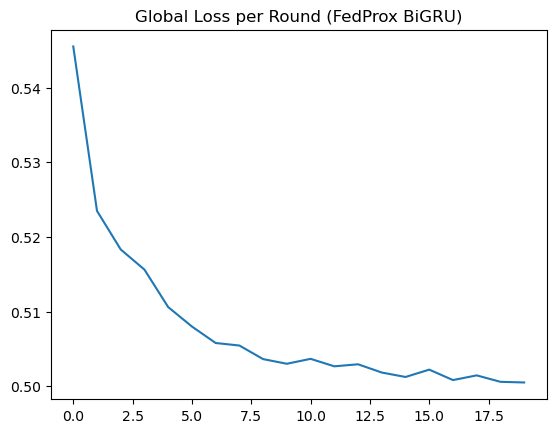

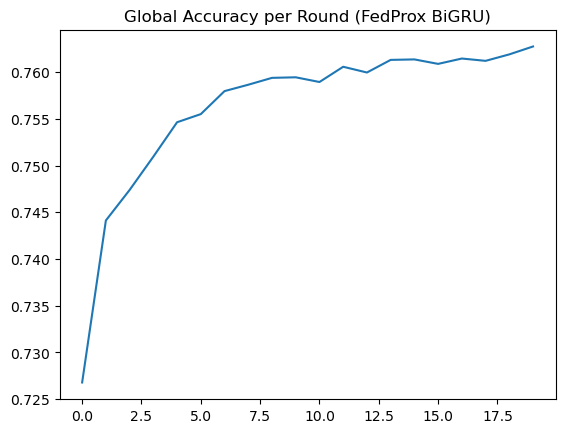

In [73]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, clone_model
from tensorflow.keras.layers import Bidirectional, GRU, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

# -------------------------------------------------
# 1. Split dataset into exactly 5 equal clients
# -------------------------------------------------
def split_clients_equal(X, y, n_clients=5):
    n = len(X)
    idx = np.random.permutation(n)
    split_size = n // n_clients
    clients = [(X[idx[i*split_size:(i+1)*split_size]],
                y[idx[i*split_size:(i+1)*split_size]]) for i in range(n_clients)]
    return clients

# -------------------------------------------------
# 2. Build BiGRU model
# -------------------------------------------------
def build_bigru(input_shape, n_classes):
    model = Sequential([
        Bidirectional(GRU(64, return_sequences=False), input_shape=input_shape),
        Dense(64, activation='relu'),
        Dense(n_classes, activation='softmax')
    ])
    return model

# -------------------------------------------------
# 3. Server aggregation
# -------------------------------------------------
def server_aggregation(global_model, local_models):
    new_weights = [np.mean(w, axis=0) for w in zip(*[m.get_weights() for m in local_models])]
    global_model.set_weights(new_weights)
    return global_model

# -------------------------------------------------
# 4. FedProx loss
# -------------------------------------------------
def fedprox_loss(mu, global_weights, local_model):
    def loss(y_true, y_pred):
        ce = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        prox = tf.add_n([tf.reduce_sum(tf.square(w - gw)) 
                         for w, gw in zip(local_model.trainable_variables, global_weights)])
        return ce + (mu / 2.0) * prox
    return loss

# -------------------------------------------------
# 5. FedProx training
# -------------------------------------------------
def model_fedprox_bigru(xtrain, ytrain, xtest, ytest,
                         n_clients=5, rounds=20, epochs=2, mu=0.01):

    # Convert to NumPy arrays
    xtrain = np.array(xtrain)
    xtest  = np.array(xtest)
    ytrain = np.array(ytrain)
    ytest  = np.array(ytest)

    # Reshape for BiGRU: (samples, timesteps, features)
    xtrain = xtrain.reshape(xtrain.shape[0], xtrain.shape[1], 1)
    xtest  = xtest.reshape(xtest.shape[0], xtest.shape[1], 1)

    # Split clients
    clients = split_clients_equal(xtrain, ytrain, n_clients)

    # Initialize global model
    global_model = build_bigru(xtrain.shape[1:], len(np.unique(ytrain)))
    global_model.compile(optimizer=Adam(0.001),
                         loss='sparse_categorical_crossentropy',
                         metrics=['accuracy'])

    global_loss, global_acc = [], []

    # Federated rounds
    for r in range(rounds):
        local_models = []
        global_weights = global_model.get_weights()

        for Xc, yc in clients:
            local_model = clone_model(global_model)
            local_model.set_weights(global_weights)
            local_model.compile(
                optimizer=Adam(0.001),
                loss=fedprox_loss(mu, global_weights, local_model),
                metrics=['accuracy']
            )
            local_model.fit(Xc, yc, epochs=epochs, batch_size=32, verbose=0)
            local_models.append(local_model)

        # Server aggregation
        global_model = server_aggregation(global_model, local_models)

        # Evaluate
        loss, acc = global_model.evaluate(xtest, ytest, verbose=0)
        global_loss.append(loss)
        global_acc.append(acc)
        print(f"Round {r+1}: Loss={loss:.4f}, Accuracy={acc:.4f}")

    # Final evaluation
    y_pred = np.argmax(global_model.predict(xtest, verbose=0), axis=1)
    print("\nClassification Report:\n", classification_report(ytest, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(ytest, y_pred))

    # Print full lists
    print("\nGlobal Loss per Round:")
    print(global_loss)
    print("\nGlobal Accuracy per Round:")
    print(global_acc)

    # Plot
    plt.figure(); plt.plot(global_loss); plt.title("Global Loss per Round (FedProx BiGRU)"); plt.show()
    plt.figure(); plt.plot(global_acc); plt.title("Global Accuracy per Round (FedProx BiGRU)"); plt.show()

    return global_model

# ------------------ CALL FUNCTION ------------------
global_model = model_fedprox_bigru(xtrain, ytrain, xtest, ytest,
                                   n_clients=5, rounds=20, epochs=2, mu=0.01)


In [78]:
Global_Loss_per_Round_BiGRU = [0.5455185770988464, 0.5234893560409546, 0.5183225870132446, 0.5156230926513672, 0.5106050968170166, 0.5080013275146484, 0.505794107913971, 0.505455732345581, 0.5036360025405884, 0.5030125379562378, 0.5036723017692566, 0.502670168876648, 0.5029427409172058, 0.5018380880355835, 0.5012418627738953, 0.5022271871566772, 0.5008280277252197, 0.5014575123786926, 0.5005937218666077, 0.5005057454109192]


Global_Accuracy_per_Round_BiGRU = [0.726773738861084, 0.7441202402114868, 0.7473860383033752, 0.7509511113166809, 0.7546358704566956, 0.7555078864097595, 0.7579700350761414, 0.758653998374939, 0.7593892216682434, 0.7594490647315979, 0.7589446902275085, 0.7605775594711304, 0.7599620223045349, 0.7613128423690796, 0.7613641023635864, 0.7608853578567505, 0.761458158493042, 0.7612102627754211, 0.7619027495384216, 0.7627490758895874]

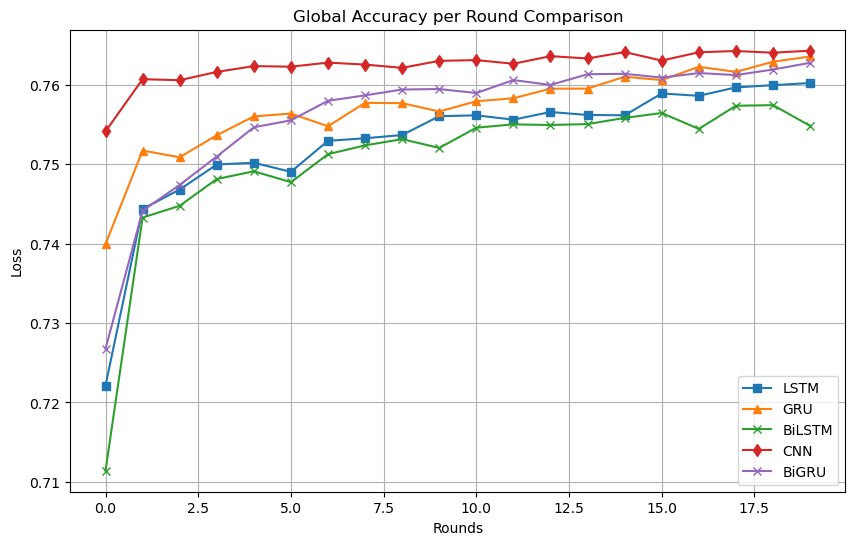

In [82]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,6))

plt.plot(Global_Accuracy_per_Round_LSTM, marker='s', label='LSTM')
plt.plot(Global_Accuracy_per_Round_GRU, marker='^', label='GRU')
plt.plot(Global_Accuracy_per_Round_BiLSTM, marker='x', label='BiLSTM')
plt.plot(global_accuracy_per_round_CNN, marker='d', label='CNN')
plt.plot(Global_Accuracy_per_Round_BiGRU, marker='x', label='BiGRU')

plt.title("Global Accuracy per Round Comparison")
plt.xlabel("Rounds")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


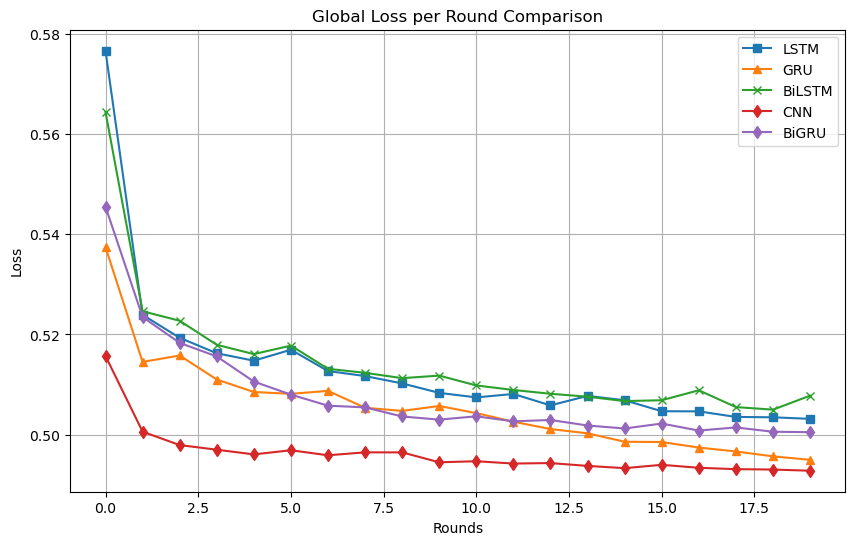

In [80]:
import matplotlib.pyplot as plt

# Plot all in one figure
plt.figure(figsize=(10,6))
plt.plot(Global_Loss_per_Round_LSTM, marker='s', label='LSTM')
plt.plot(Global_Loss_per_Round_GRU, marker='^', label='GRU')
plt.plot(Global_Loss_per_Round_BiLSTM, marker='x', label='BiLSTM')
plt.plot(global_loss_per_round_CNN, marker='d', label='CNN')
plt.plot(Global_Loss_per_Round_BiGRU, marker='d', label='BiGRU')

plt.title("Global Loss per Round Comparison")
plt.xlabel("Rounds")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()
